In [1]:
import os
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

os.chdir("..")

from experiment_utils.utils import *

sns.set_palette("colorblind")

In [2]:
responses = "data/processed/responses_processed.csv"

responses = pd.read_csv(responses)
responses.head()

,StartDate,EndDate,Status,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,DistributionChannel,UserLanguage,...,made_edits,response_time_minutes,response_quality,AnonymizedID,Anonymized_PID,LLM_impact_abbrev,att1_passed,att2_passed,passed_both_att_checks,num_edited_sentences
0,2026-05-21 14:38:41,2026-05-21 15:07:13,IP Address,100,1711,True,2026-05-21 15:07:14,R_4tvghDvC4oZm2e5,anonymous,EN,...,True,28.516667,high_quality,G1_C1,G1_C1,Very beneficial,1,1,1,9
1,2026-05-21 14:02:01,2026-05-21 14:35:16,IP Address,100,1994,True,2026-05-21 14:35:17,R_2MAJ7CWkGG77fjM,anonymous,EN,...,True,33.233333,high_quality,G1_C2,G1_C2,More negative than positive,1,1,1,9
2,2026-05-21 14:02:00,2026-05-21 14:26:42,IP Address,100,1482,True,2026-05-21 14:26:43,R_8JJzTTgaMsugyuk,anonymous,EN,...,True,24.700000,high_quality,G1_C3,G1_C3,Very detrimental,1,1,1,9
3,2026-05-21 14:02:01,2026-05-21 14:20:18,IP Address,100,1097,True,2026-05-21 14:20:19,R_8rv978TZzUt3U54,anonymous,EN,...,True,18.283333,high_quality,G1_C4,G1_C4,More negative than positive,1,1,1,10
4,2026-05-21 14:02:21,2026-05-21 14:25:20,IP Address,100,1378,True,2026-05-21 14:25:21,R_2szGwhAqpRYx3Wm,anonymous,EN,...,True,22.966667,high_quality,G1_C5,G1_C5,More positive than negative,1,1,1,13


# Prepare data

In [3]:
# rename g and c to generation and chain for clarity
responses.rename(columns={'g': 'generation', 'c': 'chain'}, inplace=True)

# reconstruct texts from sentence-based editing data
for i, row in responses.iterrows():
    gen = row['generation']
    chain = row['chain']
    edits_list = ast.literal_eval(row['decoded_edits'])
    original_sentences = []
    edited_sentences = []
    for edit in edits_list:
        orig = edit.get('orig', '').strip()
        edited = edit.get('edited', '').strip()
        original_sentences.append(orig)
        edited_sentences.append(edited)
    responses.loc[i, 'original_text'] = " ".join(original_sentences).strip()
    responses.loc[i, 'edited_text'] = " ".join(edited_sentences).strip()

In [4]:
responses[responses['made_edits'] == False][['generation', 'chain', 'original_text', 'edited_text']]

,generation,chain,original_text,edited_text
14,1,15,"For more than a century, the Congressional Bas...","For more than a century, the Congressional Bas..."
70,4,8,The Egyptian Red Sea islands of Tiran and Sana...,The Egyptian Red Sea islands of Tiran and Sana...
96,5,13,"Dr. Amelia Hart, a renown quantum physicist, h...","Dr. Amelia Hart, a renown quantum physicist, h..."


In [5]:
# for each gen => text = edited text
# add gen 0 => text = original text of gen 1

texts_data = responses[['generation', 'chain', 'edited_text']].copy()
texts_data = texts_data.rename(columns={'edited_text': 'text'})

# add gen 0 = original text of gen 1 (one per chain)
gen0 = (
    responses[responses['generation'] == 1][['chain', 'original_text']]
    .drop_duplicates('chain')
    .assign(generation=0)
    .rename(columns={'original_text': 'text'})
)

texts_data = pd.concat([gen0, texts_data]).sort_values(['generation', 'chain']).reset_index(drop=True)

texts_data.head()

,chain,text,generation
0,1,A growing number of companies are migrating to...,0
1,2,"At dawn, the marble corridors of the Beijing D...",0
2,3,"Jimmy Wales, cofounder of Wikipedia, says the ...",0
3,4,Uber Technologies is facing a significant lead...,0
4,5,Americans erupt every February for the Super B...,0


In [6]:
# get indices of unsuccessful editing cases in texts_data
unsuccessful_editing_indices = texts_data[
    (texts_data["generation"] == 5) & (texts_data["chain"].isin([7, 18]))
].index

no_editing_indices = texts_data[
    ((texts_data["generation"] == 1) & (texts_data["chain"] == 15)) |
    ((texts_data["generation"] == 4) & (texts_data["chain"] == 8))  |
    ((texts_data["generation"] == 5) & (texts_data["chain"] == 13))
].index

# Lexical diversity

## Measure of Textual Lexical Diversity (MTLD)

MTLD is computed by tracking the running type-token ratio (TTR) through the text, identifying the point at which the TTR falls below a threshold commonly fixed at 0.72, counting the resulting segments or "factors," and dividing the total number of tokens by the total number of complete and partial factors. Higher MTLD values indicate that a text sustains lexical variety over longer stretches before repetition reduces TTR.

In [7]:
# source: https://github.com/lsys/LexicalRichness 
from lexicalrichness import LexicalRichness


for i, row in texts_data.iterrows():
    text = row['text']
    lex = LexicalRichness(text)
    lexical_richness_metrics = {
        'lex_rich:ttr': lex.ttr,
        'lex_rich:rttr': lex.rttr,
        'lex_rich:cttr': lex.cttr,
        'lex_rich:herdan': lex.Herdan,
        'lex_rich:summer': lex.Summer,
        'lex_rich:dugast': lex.Dugast,
        'lex_rich:maas': lex.Maas,
        'lex_rich:yulek': lex.yulek,
        'lex_rich:yulei': lex.yulei,
        'lex_rich:herdanvm': lex.herdanvm,
        'lex_rich:simpsond': lex.simpsond,
        'lex_rich:msttr': lex.msttr(),
        'lex_rich:mattr': lex.mattr(),
        'lex_rich:mtld': lex.mtld(),
        'lex_rich:hdd': lex.hdd(),
        'lex_rich:vocd': lex.vocd()
    }
    for metric, value in lexical_richness_metrics.items():
        texts_data.loc[i, metric] = value

texts_data.head()

,chain,text,generation,lex_rich:ttr,lex_rich:rttr,lex_rich:cttr,lex_rich:herdan,lex_rich:summer,lex_rich:dugast,lex_rich:maas,lex_rich:yulek,lex_rich:yulei,lex_rich:herdanvm,lex_rich:simpsond,lex_rich:msttr,lex_rich:mattr,lex_rich:mtld,lex_rich:hdd,lex_rich:vocd
0,1,A growing number of companies are migrating to...,0,0.745283,10.851485,7.673158,0.945116,0.966367,97.598202,0.010246,56.959772,80.529032,0.063905,0.005723,0.845,0.885398,233.042963,0.906647,183.529726
1,2,"At dawn, the marble corridors of the Beijing D...",0,0.776119,11.003392,7.780573,0.952209,0.970647,110.969284,0.009012,60.889582,83.628866,0.068219,0.006119,0.845,0.870098,251.384000,0.906344,184.824234
2,3,"Jimmy Wales, cofounder of Wikipedia, says the ...",0,0.757576,10.660036,7.537784,0.947500,0.967620,100.729724,0.009928,50.505051,91.463415,0.058603,0.005076,0.850,0.836061,228.690000,0.913954,204.453701
3,4,Uber Technologies is facing a significant lead...,0,0.758794,10.704106,7.568946,0.947854,0.967863,101.509201,0.009851,55.049115,85.718045,0.062510,0.005533,0.820,0.830100,231.005833,0.910980,195.778107
4,5,Americans erupt every February for the Super B...,0,0.738693,10.420554,7.368444,0.942782,0.964643,92.511206,0.010810,88.886644,53.487624,0.084327,0.008934,0.760,0.835900,213.236154,0.881089,139.366574


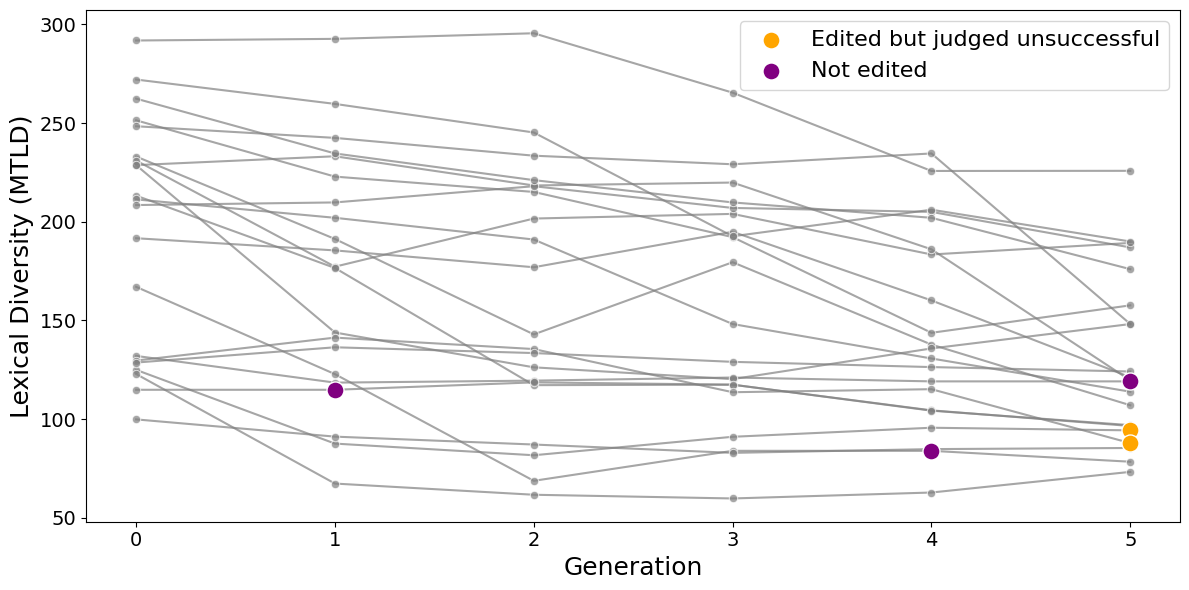

In [8]:
# plot mtld per gen and chain
plt.figure(figsize=(12, 6))
sns.lineplot(data=texts_data, x='generation', y='lex_rich:mtld', units='chain', estimator=None, marker='o', color='gray', alpha=0.7)
sns.scatterplot(data=texts_data.loc[unsuccessful_editing_indices], x="generation", y="lex_rich:mtld", color="orange", s=150, label="Edited but judged unsuccessful", zorder=10)
sns.scatterplot(data=texts_data.loc[no_editing_indices], x="generation", y="lex_rich:mtld", color="purple", s=150, label="Not edited", zorder=10)
# plt.title('Lexical Diversity (MTLD) Across Generations by Chain')
plt.xlabel('Generation', fontsize=18)
plt.xticks(range(0, 6), fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel('Lexical Diversity (MTLD)', fontsize=18)
plt.legend(fontsize=16)
# plt.grid()
plt.tight_layout()
# plt.savefig("analysis/figs/sustainability/mtld_unsuccessful.pdf", bbox_inches='tight')
plt.show()

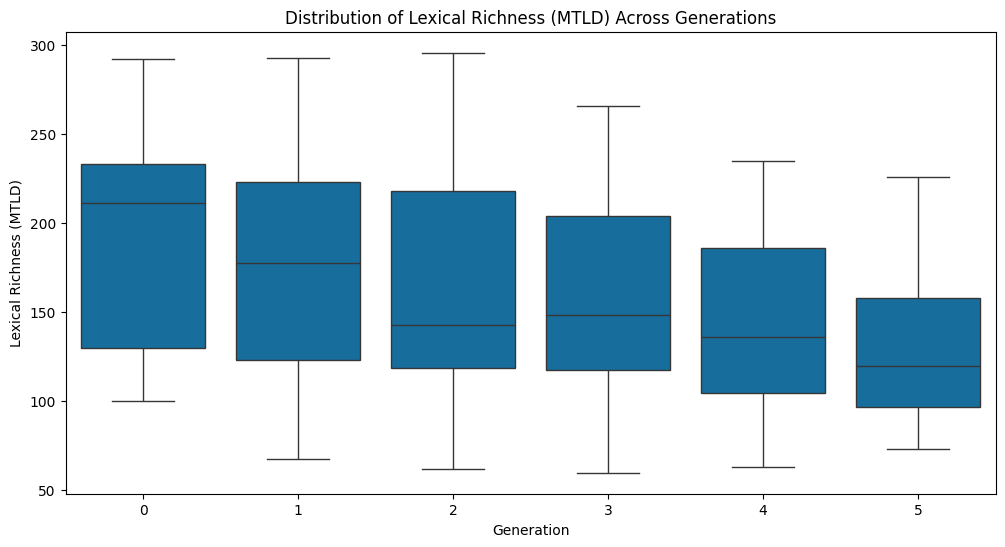

In [9]:
# boxplot of mtld per generation
plt.figure(figsize=(12, 6))
sns.boxplot(data=texts_data, x='generation', y='lex_rich:mtld')
plt.title('Distribution of Lexical Richness (MTLD) Across Generations')
plt.xlabel('Generation')
plt.xticks(range(0, 6))
plt.ylabel('Lexical Richness (MTLD)')
# plt.grid()
plt.show()

## Correlation of lexical diversity features

,lex_rich:ttr,lex_rich:rttr,lex_rich:cttr,lex_rich:herdan,lex_rich:summer,lex_rich:dugast,lex_rich:maas,lex_rich:yulek,lex_rich:yulei,lex_rich:herdanvm,lex_rich:simpsond,lex_rich:msttr,lex_rich:mattr,lex_rich:mtld,lex_rich:hdd,lex_rich:vocd
lex_rich:ttr,1.000000,0.724965,0.724965,0.991036,0.978710,0.947521,-0.967603,-0.840073,0.899398,-0.786990,-0.839719,0.873760,0.912378,0.909791,0.913906,0.885925
lex_rich:rttr,0.724965,1.000000,1.000000,0.802458,0.843156,0.810256,-0.869715,-0.698825,0.700422,-0.577972,-0.700144,0.825350,0.814823,0.841003,0.813526,0.749278
lex_rich:cttr,0.724965,1.000000,1.000000,0.802458,0.843156,0.810256,-0.869715,-0.698825,0.700422,-0.577972,-0.700144,0.825350,0.814823,0.841003,0.813526,0.749278
lex_rich:herdan,0.991036,0.802458,0.802458,1.000000,0.997136,0.948416,-0.991569,-0.849766,0.886337,-0.778799,-0.849691,0.902469,0.937793,0.921372,0.932465,0.884976
lex_rich:summer,0.978710,0.843156,0.843156,0.997136,1.000000,0.949050,-0.998395,-0.848502,0.879861,-0.768812,-0.848610,0.912585,0.943942,0.927116,0.937278,0.884843
lex_rich:dugast,0.947521,0.810256,0.810256,0.948416,0.949050,1.000000,-0.952482,-0.807151,0.938624,-0.750507,-0.807324,0.870978,0.882276,0.957067,0.903129,0.929882
lex_rich:maas,-0.967603,-0.869715,-0.869715,-0.991569,-0.998395,-0.952482,1.000000,0.844915,-0.879206,0.760695,0.845159,-0.916763,-0.943636,-0.933459,-0.938624,-0.887950
lex_rich:yulek,-0.840073,-0.698825,-0.698825,-0.849766,-0.848502,-0.807151,0.844915,1.000000,-0.894390,0.982055,0.999997,-0.842727,-0.842880,-0.835248,-0.963673,-0.908812
lex_rich:yulei,0.899398,0.700422,0.700422,0.886337,0.879861,0.938624,-0.879206,-0.894390,1.000000,-0.891528,-0.894362,0.842848,0.844270,0.907871,0.933358,0.990643
lex_rich:herdanvm,-0.786990,-0.577972,-0.577972,-0.778799,-0.768812,-0.750507,0.760695,0.982055,-0.891528,1.000000,0.981800,-0.774698,-0.769988,-0.774744,-0.920768,-0.897509


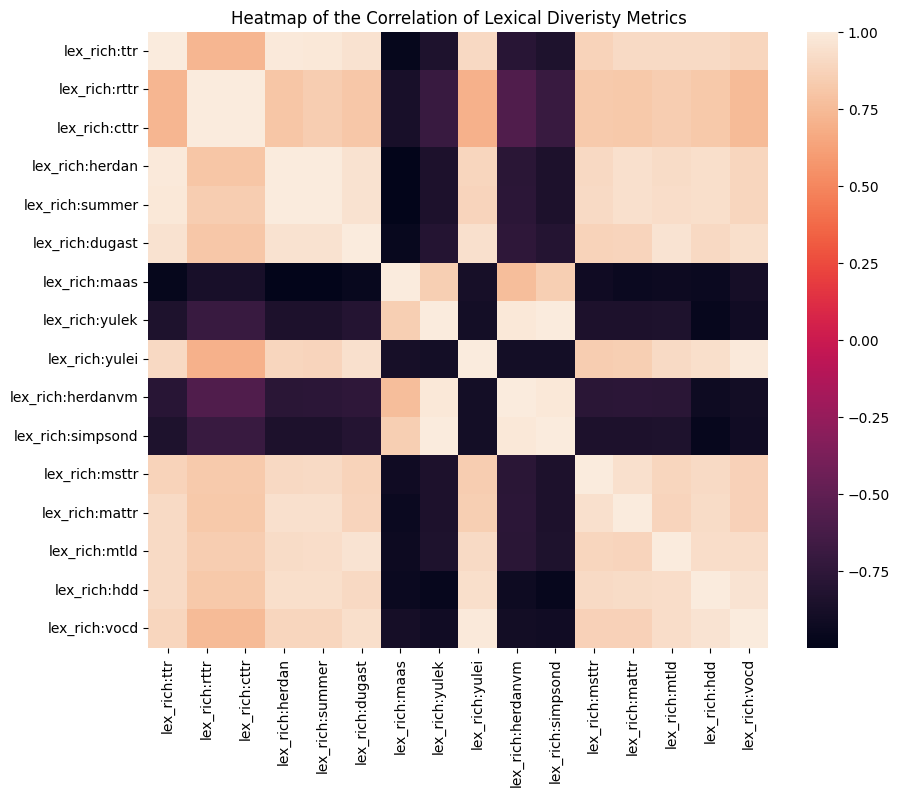

In [10]:
# compute correlation between lexical diversity metrics

lex_rich_cols = [c for c in texts_data if 'lex_rich' in c]

lex_rich_corr = texts_data[lex_rich_cols].corr()
display(lex_rich_corr)

# heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(lex_rich_corr)
plt.title('Heatmap of the Correlation of Lexical Diveristy Metrics')
plt.show()

In [11]:
# find the metric that is most central (highest average correlation with the others)
avg_corr = lex_rich_corr.apply(lambda x: abs(x)).mean().sort_values(ascending=False)
display(avg_corr)

most_central_metric = avg_corr.idxmax()
print(f"Most central metric: {most_central_metric} (average correlation: {avg_corr[most_central_metric]})")

lex_rich:hdd         0.921726
lex_rich:maas        0.912493
lex_rich:summer      0.910072
lex_rich:herdan      0.904796
lex_rich:mtld        0.893514
lex_rich:vocd        0.892711
lex_rich:dugast      0.891557
lex_rich:ttr         0.887296
lex_rich:mattr       0.884272
lex_rich:yulei       0.880221
lex_rich:msttr       0.877137
lex_rich:simpsond    0.866344
lex_rich:yulek       0.866115
lex_rich:herdanvm    0.812177
lex_rich:cttr        0.798243
lex_rich:rttr        0.798243
dtype: float64

Most central metric: lex_rich:hdd (average correlation: 0.9217260005050509)


In [12]:
# pair of features with the least correlation (closest to 0) 
smallest_corr = lex_rich_corr.apply(lambda x: abs(x)).min()

least_correlated_pairs = []
for col in lex_rich_corr.columns:
    min_corr = smallest_corr[col]
    pair = lex_rich_corr[col][lex_rich_corr[col].abs() == min_corr].index[0]
    least_correlated_pairs.append((col, pair, min_corr))

least_correlated_pairs_df = pd.DataFrame(least_correlated_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])
least_correlated_pairs_df.sort_values('Correlation')

,Feature 1,Feature 2,Correlation
2,lex_rich:cttr,lex_rich:herdanvm,0.577972
9,lex_rich:herdanvm,lex_rich:cttr,0.577972
1,lex_rich:rttr,lex_rich:herdanvm,0.577972
7,lex_rich:yulek,lex_rich:rttr,0.698825
10,lex_rich:simpsond,lex_rich:rttr,0.700144
8,lex_rich:yulei,lex_rich:rttr,0.700422
0,lex_rich:ttr,lex_rich:rttr,0.724965
15,lex_rich:vocd,lex_rich:cttr,0.749278
5,lex_rich:dugast,lex_rich:herdanvm,0.750507
6,lex_rich:maas,lex_rich:herdanvm,0.760695


# Syntactic complexity

## Mean dependency distance

It is computed as the average linear distance between syntactically linked words in the dependency parse of a text. Higher values indicate that syntactic dependencies span longer distances on average and are interpreted as reflecting greater syntactic complexity.

In [13]:
import textdescriptives as td

td.get_valid_metrics()

{'all',
 'coherence',
 'dependency_distance',
 'descriptive_stats',
 'information_theory',
 'pos_proportions',
 'quality',
 'readability'}

In [14]:
metrics_dict = {}

text = texts_data.loc[0, 'text']

for metric in td.get_valid_metrics():
    if metric in ['all', 'quality']:
        continue
    print(f"Metrics in {metric}:")
    df = td.extract_metrics(text=text, spacy_model="en_core_web_lg", metrics=[metric])
    print(df.columns, "\n")
    metrics_dict[metric] = df.columns.tolist()


Metrics in descriptive_stats:
Index(['text', 'token_length_mean', 'token_length_median', 'token_length_std',
       'sentence_length_mean', 'sentence_length_median', 'sentence_length_std',
       'syllables_per_token_mean', 'syllables_per_token_median',
       'syllables_per_token_std', 'n_tokens', 'n_unique_tokens',
       'proportion_unique_tokens', 'n_characters', 'n_sentences'],
      dtype='object') 

Metrics in readability:
Index(['text', 'token_length_mean', 'token_length_median', 'token_length_std',
       'sentence_length_mean', 'sentence_length_median', 'sentence_length_std',
       'syllables_per_token_mean', 'syllables_per_token_median',
       'syllables_per_token_std', 'n_tokens', 'n_unique_tokens',
       'proportion_unique_tokens', 'n_characters', 'n_sentences',
       'flesch_reading_ease', 'flesch_kincaid_grade', 'smog', 'gunning_fog',
       'automated_readability_index', 'coleman_liau_index', 'lix', 'rix'],
      dtype='object') 

Metrics in coherence:
Index(['text'

In [15]:
import spacy
nlp = spacy.load("en_core_web_lg")

# metrics to extract (excluding quality due to bug)
stable_metrics = [
    "textdescriptives/coherence",
    "textdescriptives/dependency_distance",
    # "textdescriptives/descriptive_stats", # fully contained in readability component
    "textdescriptives/information_theory",
    "textdescriptives/pos_proportions",
    # "textdescriptives/quality", # due to bug (fixed below)
    "textdescriptives/readability",
]

for component in stable_metrics:
    nlp.add_pipe(component)

# fix quality component bug 
# the error:
    # Config error for 'textdescriptives/quality'
    # textdescriptives/quality -> top_ngram_range	at root: [2, 4] is not typing.Tuple[int, int]
    # textdescriptives/quality -> duplicate_n_gram_fraction_range	at root: [5, 10] is not typing.Tuple[int, int]
    # {'nlp': <spacy.lang.en.English object at 0x15e4cb710>, 'name': 'textdescriptives/quality', 'top_ngram_range': [2, 4], 'top_ngram_min_count': 3, 'duplicate_n_gram_fraction_range': [5, 10], 'vocab': None, 'force': True, '@factories': 'textdescriptives/quality'}
# => add it manually with explicit config

nlp.add_pipe(
    "textdescriptives/quality", 
    config={
        "top_ngram_range": (2, 4),                    
        "duplicate_n_gram_fraction_range": (5, 10)    
    }
)

docs = list(nlp.pipe(texts_data['text']))
td_df = td.extract_df(docs)

# rename all columns with prefix and merge back
td_df = td_df.rename(columns={col: f'text_desc:{col}' for col in td_df.columns})
texts_data = pd.concat([texts_data, td_df], axis=1)
# drop "text" column
texts_data = texts_data.drop(columns=['text_desc:text'])

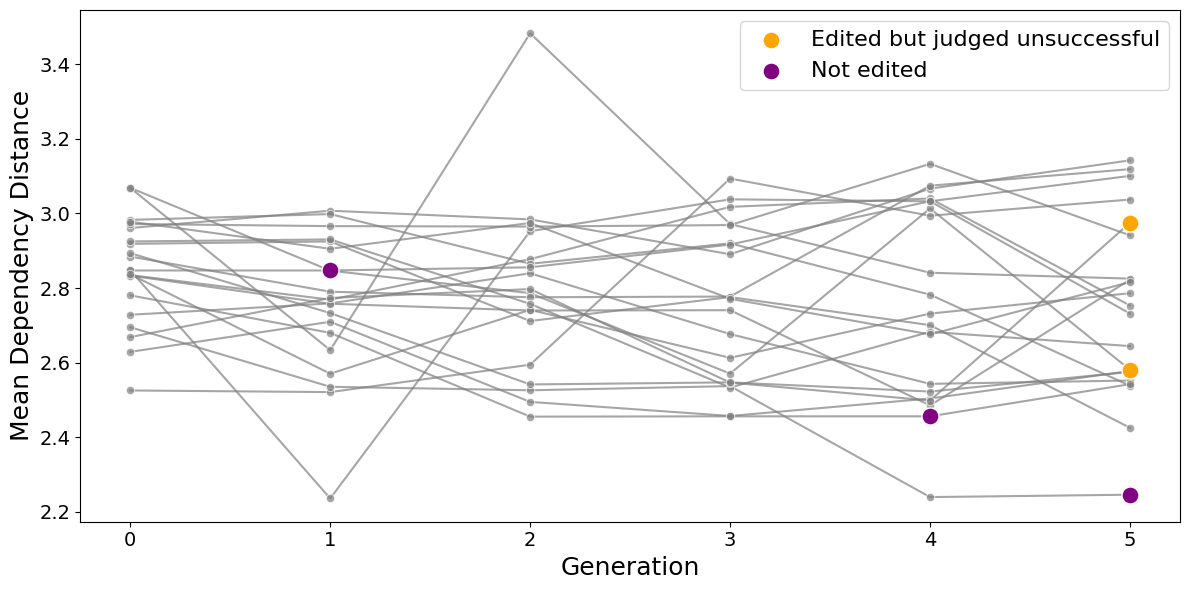

In [16]:
# plot mean dependency distance per gen and chain
plt.figure(figsize=(12, 6))
sns.lineplot(data=texts_data, x='generation', y='text_desc:dependency_distance_mean', units='chain', estimator=None, marker='o', color='gray', alpha=0.7)
sns.scatterplot(data=texts_data.loc[unsuccessful_editing_indices], x="generation", y="text_desc:dependency_distance_mean", color="orange", s=150, label="Edited but judged unsuccessful", zorder=10)
sns.scatterplot(data=texts_data.loc[no_editing_indices], x="generation", y="text_desc:dependency_distance_mean", color="purple", s=150, label="Not edited", zorder=10)
# plt.title('Mean Dependency Distance Across Generations by Chain')
plt.xlabel('Generation', fontsize=18)
plt.xticks(range(0, 6), fontsize=14)
plt.ylabel('Mean Dependency Distance', fontsize=18)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)
plt.tight_layout()
# plt.savefig("analysis/figs/sustainability/dep_dist_unsuccessful.pdf", bbox_inches='tight')
plt.show()

## Sentence length

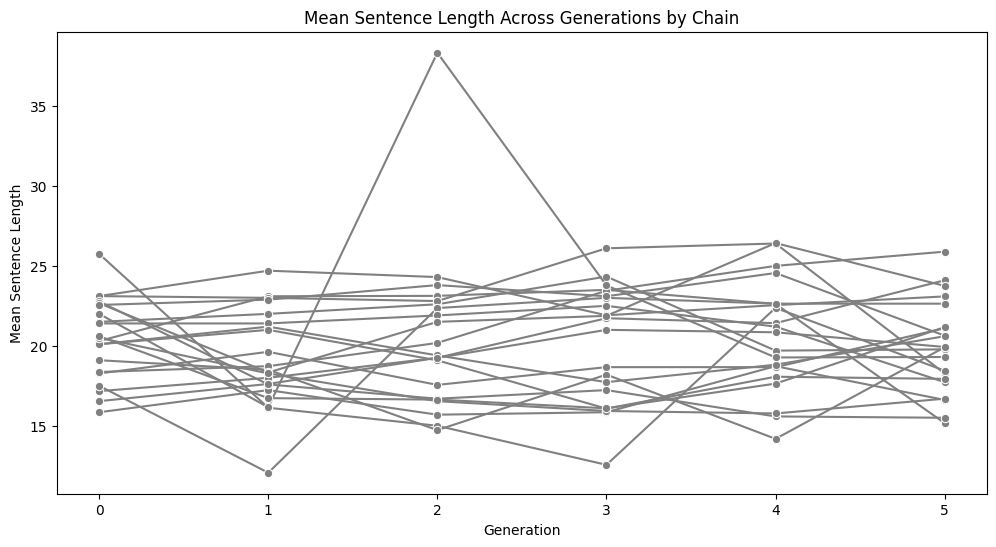

In [17]:
# plot mean dependency distance per gen and chain
plt.figure(figsize=(12, 6))
sns.lineplot(data=texts_data, x='generation', y='text_desc:sentence_length_mean', units='chain', estimator=None, marker='o', color='gray')
plt.title('Mean Sentence Length Across Generations by Chain')
plt.xlabel('Generation')
plt.xticks(range(0, 6))
plt.ylabel('Mean Sentence Length')
# plt.grid()
plt.show()

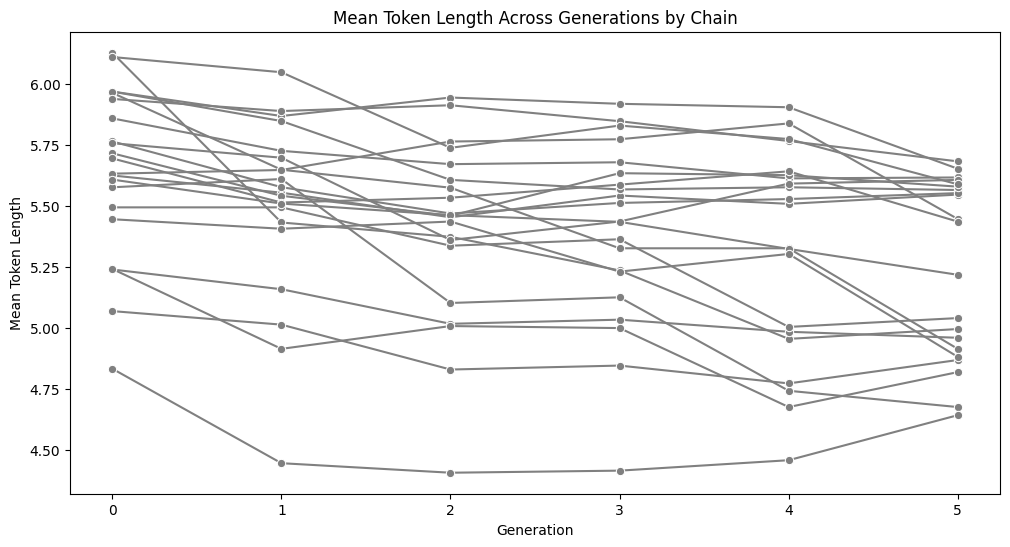

In [18]:
# plot mean dependency distance per gen and chain
plt.figure(figsize=(12, 6))
sns.lineplot(data=texts_data, x='generation', y='text_desc:token_length_mean', units='chain', estimator=None, marker='o', color='gray')
plt.title('Mean Token Length Across Generations by Chain')
plt.xlabel('Generation')
plt.xticks(range(0, 6))
plt.ylabel('Mean Token Length')
# plt.grid()
plt.show()

# Correctness

## Error rate

It is measured as the number of retained typos, grammar, casing, and punctuation alerts per 100 words. Alerts will be identified using LanguageTool through its Python wrapper. For each text, the error rate will be computed as the number of LanguageTool alerts per 100 words. 

In [19]:
# compute word count per text 
# using lexical richness library because it is more accurate than len(text.split()) as it handles punctuation better

texts_data['word_count'] = texts_data['text'].apply(lambda x: LexicalRichness(x).words)

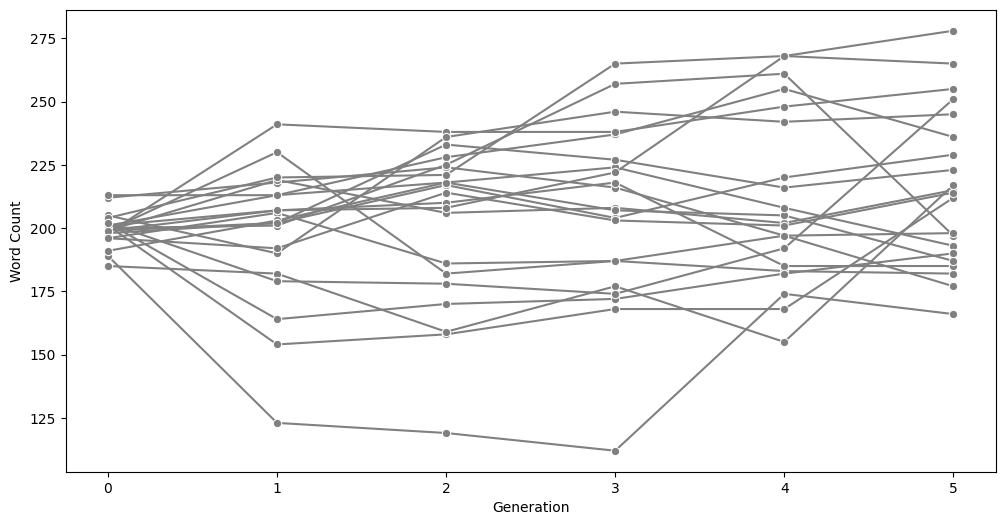

In [20]:
# plot word count per gen and chain
plt.figure(figsize=(12, 6))
sns.lineplot(x='generation', y='word_count', data=texts_data, units='chain', estimator=None, marker='o', color='gray')
# plt.title('Word Count Across Generations by Chain')
plt.xlabel('Generation')
plt.xticks(range(0, 6))
plt.ylabel('Word Count')
# plt.grid()
plt.show()


In [21]:
import language_tool_python # requires Java installed

tool_us = language_tool_python.LanguageTool('en-US')
tool_gb = language_tool_python.LanguageTool('en-GB')

def count_errors(text):
    matches_us = tool_us.check(text)
    matches_gb = tool_gb.check(text)
    
    # keep only matches flagged by both tools (ignores US/GB spelling differences)
    us_ids = {(m.offset, m.category, m.rule_id) for m in matches_us}
    gb_ids = {(m.offset, m.category, m.rule_id) for m in matches_gb}
    shared = us_ids & gb_ids  # intersection
    
    matches = [m for m in matches_us if (m.offset, m.category, m.rule_id) in shared]
    # categories: 'GRAMMAR', 'TYPOS', 'PUNCTUATION', 'STYLE', 'CASING'
    overall = [m for m in matches if m.category not in ('STYLE',)]
    # style = [m for m in matches if m.category in ('STYLE',)]
    typos = [m for m in matches if m.category in ('TYPOS',)]
    grammar = [m for m in matches if m.category in ('GRAMMAR',)]
    punctuation = [m for m in matches if m.category in ('PUNCTUATION',)]
    casing = [m for m in matches if m.category in ('CASING',)]
    
    errors_per_category = {
        'error_count_overall': len(overall),
        'error_count_typos': len(typos),
        'error_count_grammar': len(grammar),
        'error_count_punctuation': len(punctuation),
        'error_count_casing': len(casing),
        # 'error_count_style': len(style)
    }
    return errors_per_category
    # return (len(matches) / words) * 100

# texts_data['error_rate'] = texts_data['text'].apply(error_rate)

error_counts = texts_data['text'].apply(count_errors)
error_counts_df = pd.DataFrame(error_counts.tolist())
texts_data = pd.concat([texts_data, error_counts_df], axis=1)


In [22]:
texts_data.describe()

,chain,generation,lex_rich:ttr,lex_rich:rttr,lex_rich:cttr,lex_rich:herdan,lex_rich:summer,lex_rich:dugast,lex_rich:maas,lex_rich:yulek,...,text_desc:prop_adjacent_dependency_relation_std,text_desc:entropy,text_desc:perplexity,text_desc:per_word_perplexity,word_count,error_count_overall,error_count_typos,error_count_grammar,error_count_punctuation,error_count_casing
count,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,...,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000
mean,11.000000,2.500000,0.689249,9.835746,6.954923,0.929226,0.955958,79.645613,0.013313,92.096412,...,0.062246,6.420410,1478.205127,5.467413,205.515873,1.031746,0.071429,0.142857,0.111111,0.126984
std,6.079474,1.714643,0.063955,0.973881,0.688638,0.017469,0.011243,19.590290,0.003260,32.546789,...,0.014201,1.215840,3265.815312,10.850109,29.179920,1.391037,0.287849,0.394244,0.362706,0.551132
min,1.000000,0.000000,0.520325,7.425258,5.250450,0.881333,0.925943,46.388698,0.007482,40.398940,...,0.021007,3.434504,31.016038,0.230727,112.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,1.000000,0.655132,9.345865,6.608525,0.921550,0.950735,66.840377,0.010991,67.082959,...,0.054768,5.686514,294.893006,1.324817,189.250000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,11.000000,2.500000,0.690972,10.045950,7.103560,0.929824,0.956778,77.189318,0.012955,87.099038,...,0.062358,6.341247,567.525305,2.397790,203.500000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,16.000000,4.000000,0.730509,10.484569,7.413710,0.940948,0.963722,90.986474,0.014961,118.252834,...,0.072260,7.157755,1284.214816,5.309047,220.000000,2.000000,0.000000,0.000000,0.000000,0.000000
max,21.000000,5.000000,0.823171,11.667182,8.249943,0.961844,0.976121,133.657522,0.021557,183.464188,...,0.096859,10.097360,24278.825210,76.109170,278.000000,9.000000,2.000000,2.000000,2.000000,5.000000


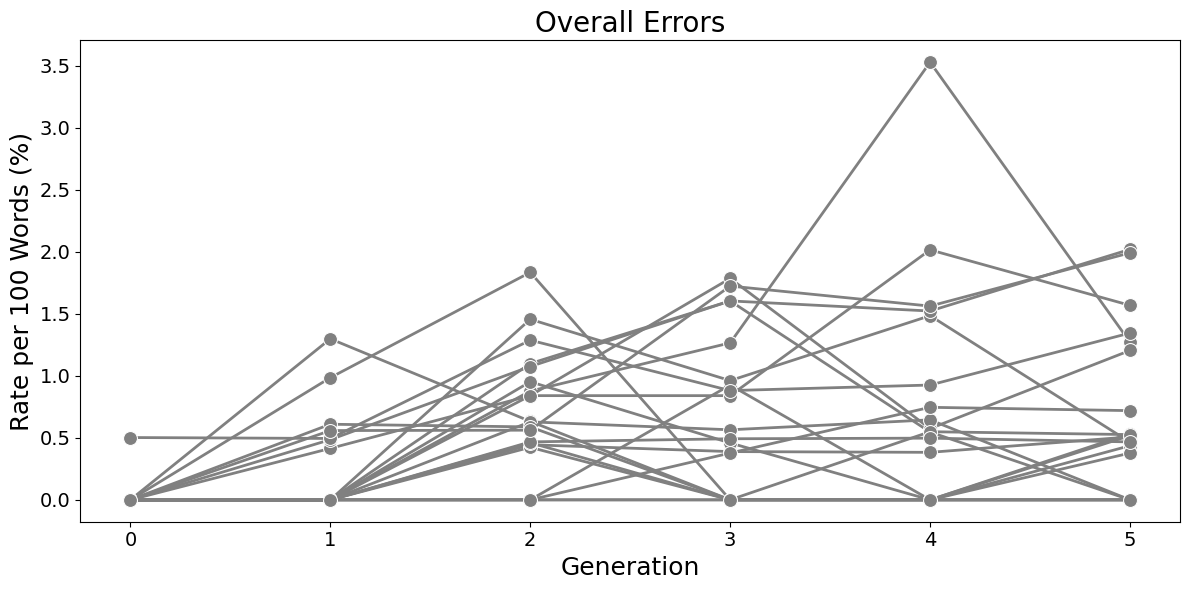

In [23]:
# plot overall error count 

error_rate = (texts_data['error_count_overall'] / texts_data['word_count']) * 100
plt.figure(figsize=(12, 6))
chain_colors = sns.color_palette("husl", n_colors=21)
sns.lineplot(data=texts_data, x='generation', y=error_rate, units='chain', estimator=None, marker='o', color='gray', linewidth=2, markersize=10, legend=False)
plt.title('Overall Errors', fontsize=20)
plt.xlabel('Generation', fontsize=18)
plt.xticks(range(0, 6), fontsize=14)
plt.ylabel(f'Rate per 100 Words (%)', fontsize=18)
plt.yticks(fontsize=14)
plt.tight_layout()
# plt.savefig(f"analysis/figs/exploratory_errors/error_count_overall.pdf", bbox_inches='tight')
plt.show()

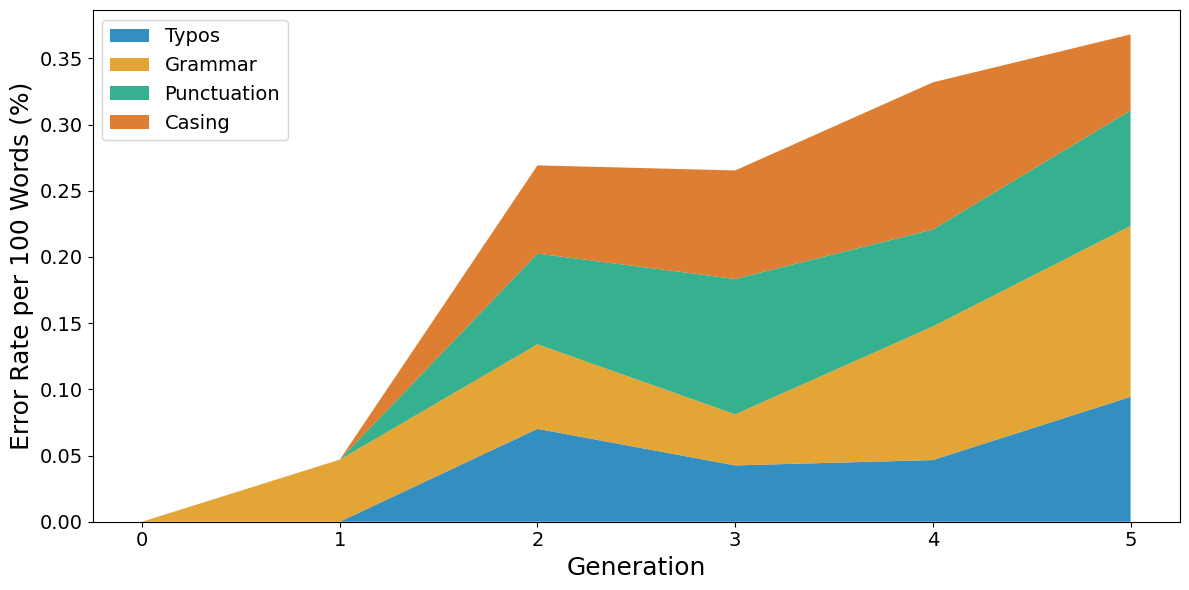

In [24]:
# stacked area plot for distribution of error types across generations

error_categories = ['error_count_typos', 'error_count_grammar', 'error_count_punctuation', 'error_count_casing'] #, 'error_count_style']
error_category_names = ['Typos', 'Grammar', 'Punctuation', 'Casing'] #, 'Style']

error_rates = texts_data[error_categories].div(texts_data['word_count'], axis=0) * 100
error_rates['generation'] = texts_data['generation']
error_rates_grouped = error_rates.groupby('generation').mean().reset_index()
plt.figure(figsize=(12, 6)) 
plt.stackplot(error_rates_grouped['generation'], 
              error_rates_grouped[error_categories].T, 
              labels=error_category_names, alpha=0.8)
# plt.title('Distribution of Error Types Across Generations')
plt.xlabel('Generation', fontsize=18)
plt.xticks(range(0, 6), fontsize=14)
plt.ylabel('Error Rate per 100 Words (%)', fontsize=18)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)   
# plt.grid()
plt.tight_layout()
# plt.savefig("analysis/figs/exploratory_errors/error_type_distribution_stacked_area.pdf", bbox_inches='tight')
plt.show()

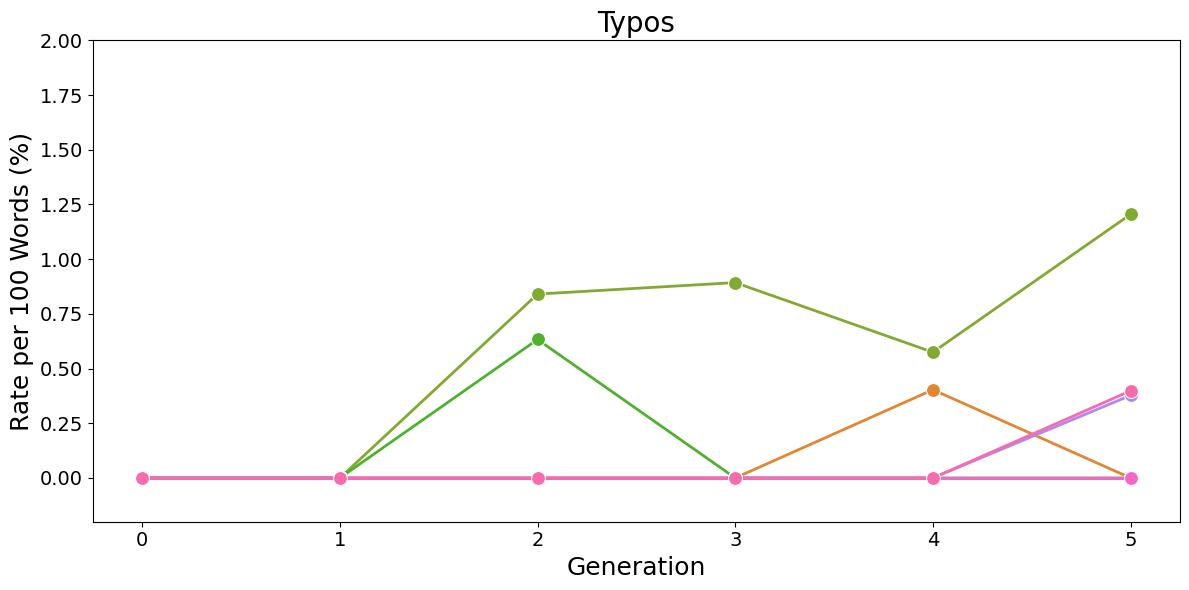

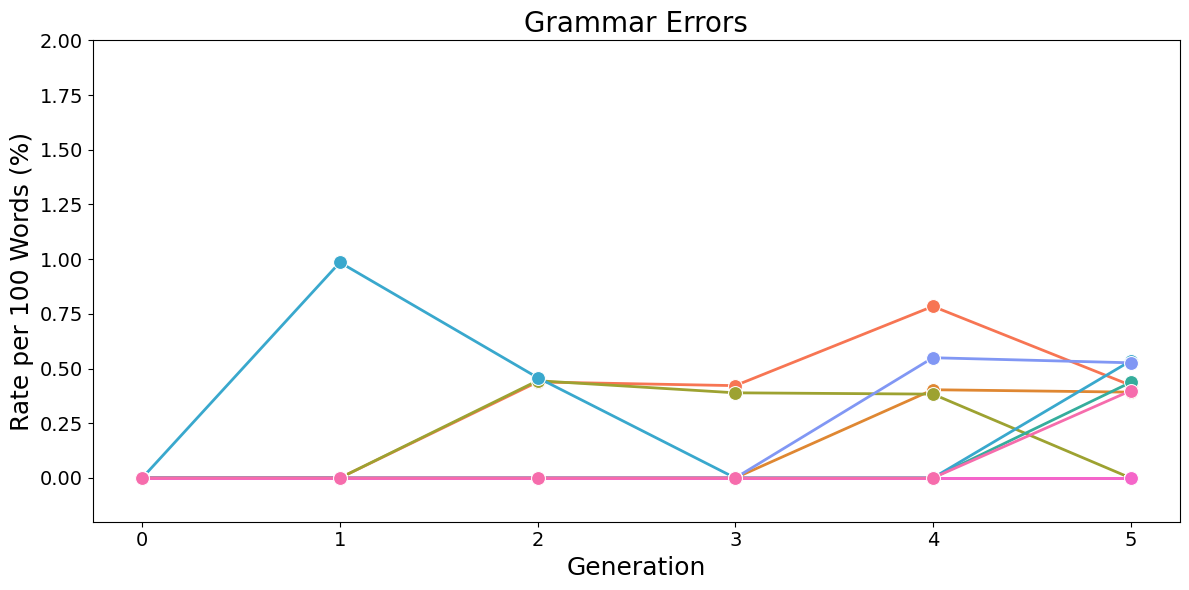

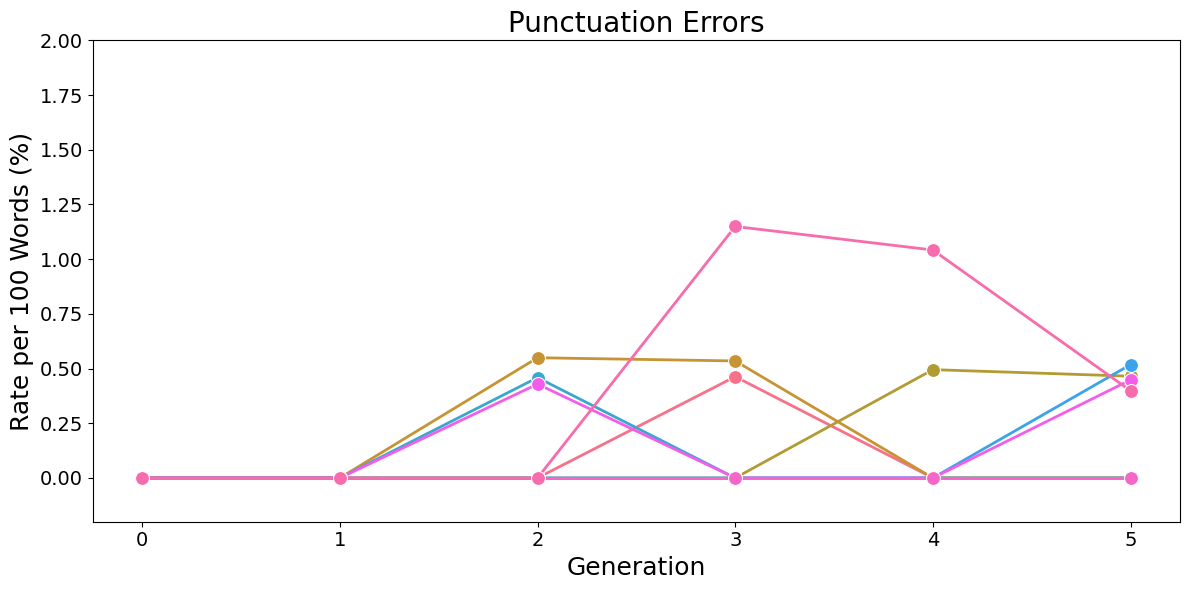

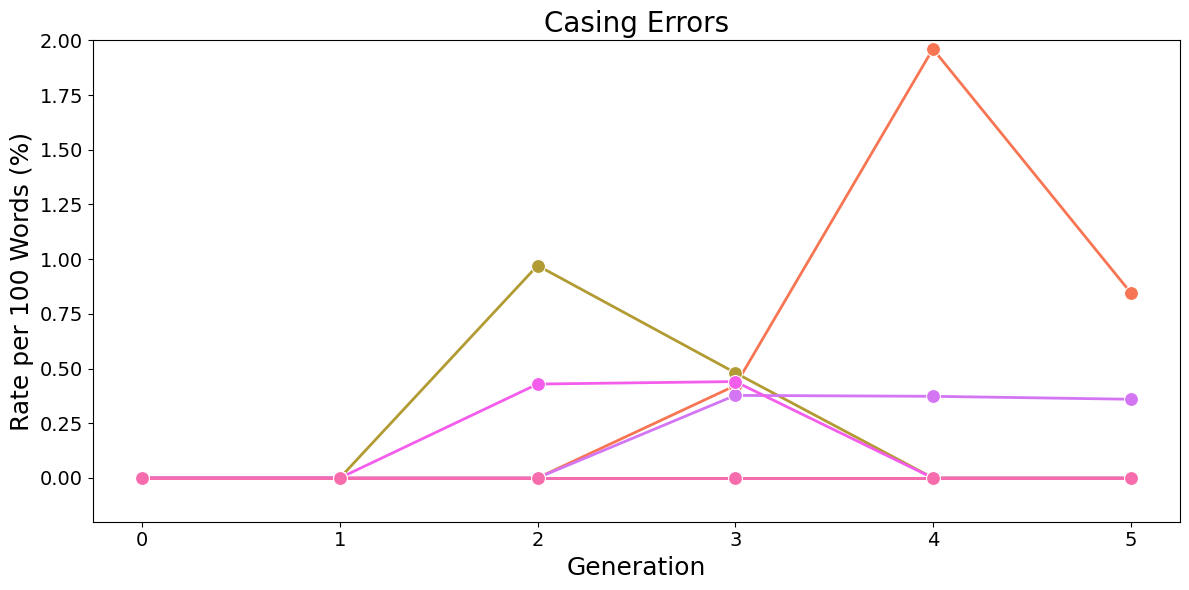

In [26]:
# plot each error category

error_categories = ['error_count_overall', 'error_count_typos', 'error_count_grammar', 'error_count_punctuation', 'error_count_casing']

for i, category in enumerate(error_categories[1:]):
    addition = ' Errors' if category != 'error_count_typos' else ''
    category_str = category.replace('error_count_', '').capitalize() + addition
    # normalize error counts by word count to get error rate per 100 words
    error_rate = (texts_data[f'{category}'] / texts_data['word_count']) * 100
    plt.figure(figsize=(12, 6))
    chain_colors = sns.color_palette("husl", n_colors=21)
    sns.lineplot(data=texts_data, x='generation', y=error_rate, hue='chain', marker='o', linewidth=2, markersize=10, palette=chain_colors, legend=False)
    plt.title(category_str, fontsize=20)
    plt.xlabel('Generation', fontsize=18)
    plt.xticks(range(0, 6), fontsize=14)
    plt.ylabel(f'Rate per 100 Words (%)', fontsize=18)
    plt.ylim(-0.2, 2)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    # plt.savefig(f"analysis/figs/exploratory_errors/{category}.pdf", bbox_inches='tight')
    plt.show()

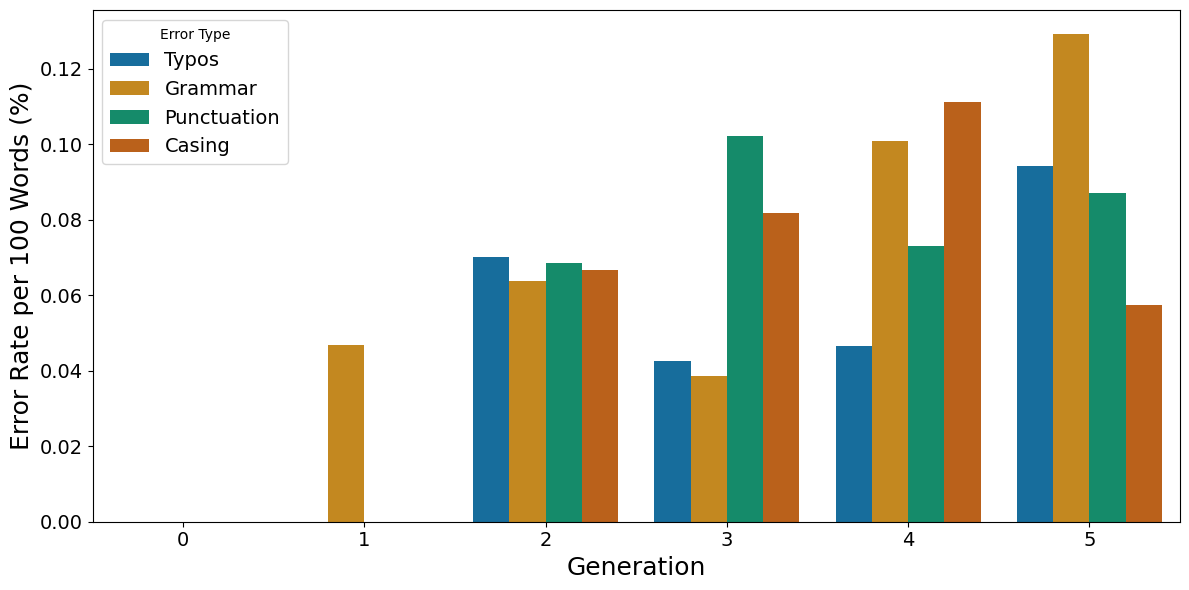

In [27]:
# bar plot for distribution of error types across generations

error_categories = ['error_count_typos', 'error_count_grammar', 'error_count_punctuation', 'error_count_casing']
error_category_names = ['Typos', 'Grammar', 'Punctuation', 'Casing']

error_rates = texts_data[error_categories].div(texts_data['word_count'], axis=0) * 100
error_rates['generation'] = texts_data['generation']   
error_rates_melted = error_rates.melt(id_vars='generation', var_name='error_type', value_name='error_rate')
plt.figure(figsize=(12, 6))
sns.barplot(data=error_rates_melted, x='generation', y='error_rate', hue='error_type', errorbar=None)
# plt.title('Distribution of Error Types Across Generations')
plt.xlabel('Generation', fontsize=18)
plt.xticks(range(0, 6), fontsize=14)
plt.ylabel('Error Rate per 100 Words (%)', fontsize=18)
plt.yticks(fontsize=14)
plt.legend(title='Error Type', labels=error_category_names, fontsize=14)
# plt.grid()
plt.tight_layout()
# plt.savefig("analysis/figs/exploratory_errors/error_type_distribution.pdf", bbox_inches='tight')
plt.show()

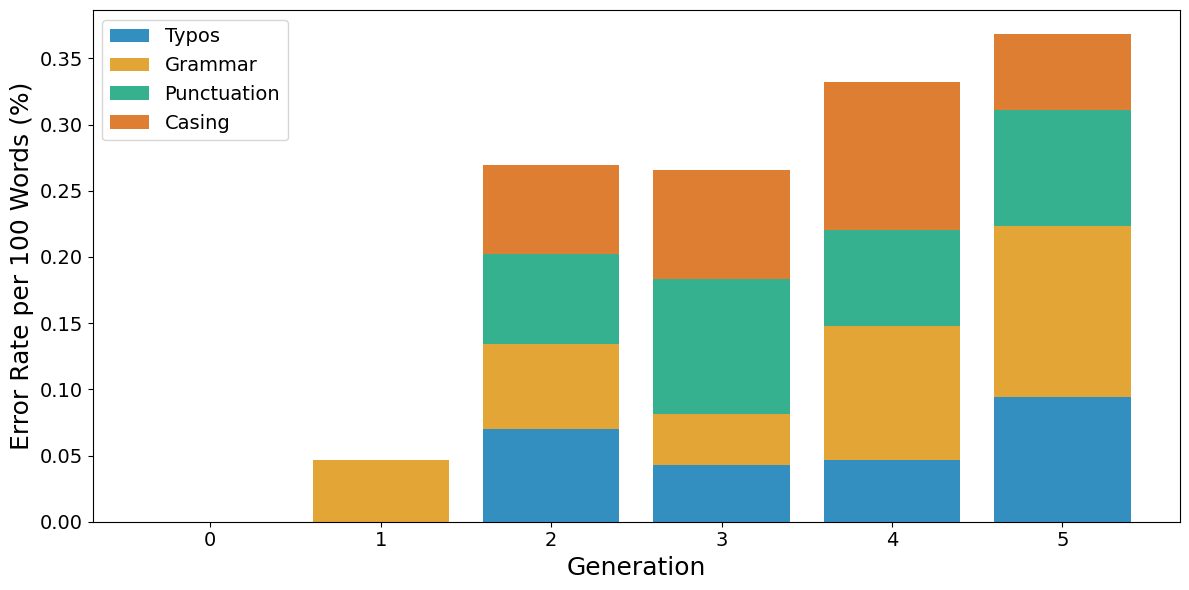

In [28]:
# stacked bar plot for distribution of error types across generations

error_categories = ['error_count_typos', 'error_count_grammar', 'error_count_punctuation', 'error_count_casing']
error_category_names = ['Typos', 'Grammar', 'Punctuation', 'Casing']

error_rates = texts_data[error_categories].div(texts_data['word_count'], axis=0) * 100
error_rates['generation'] = texts_data['generation']
error_rates_grouped = error_rates.groupby('generation').mean().reset_index()

plt.figure(figsize=(12, 6))
x = error_rates_grouped['generation']
bottom = None

for i, category in enumerate(error_categories):
    if bottom is None:
        plt.bar(x, error_rates_grouped[category], label=error_category_names[i], alpha=0.8)
        bottom = error_rates_grouped[category]
    else:
        plt.bar(x, error_rates_grouped[category], bottom=bottom, label=error_category_names[i], alpha=0.8)
        bottom = bottom + error_rates_grouped[category]

# plt.title('Distribution of Error Types Across Generations')
plt.xlabel('Generation', fontsize=18)
plt.xticks(range(0, 6), fontsize=14)
plt.ylabel('Error Rate per 100 Words (%)', fontsize=18)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)   
# plt.grid()
plt.tight_layout()
# plt.savefig("analysis/figs/exploratory_errors/error_type_distribution_stacked_bar.pdf", bbox_inches='tight')
plt.show()

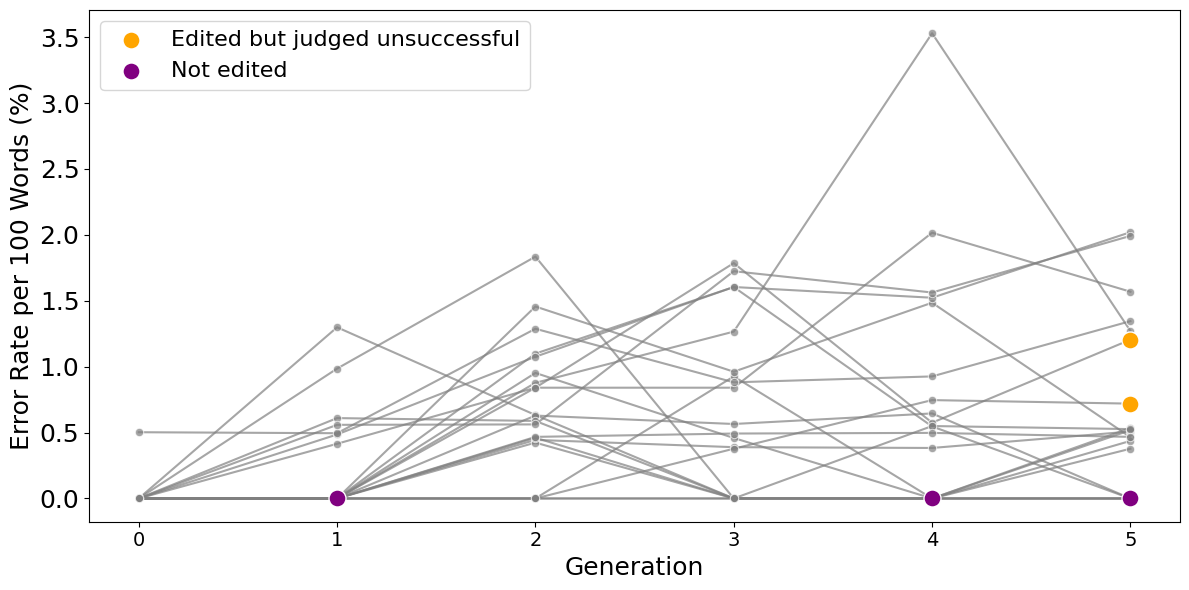

In [29]:
error_rate = (texts_data['error_count_overall'] / texts_data['word_count']) * 100
cases = texts_data[(texts_data['generation'] == 5) & (texts_data['chain'].isin([7, 18]))]
error_rate_cases = (cases['error_count_overall'] / cases['word_count']) * 100

plt.figure(figsize=(12, 6))
sns.lineplot(data=texts_data, x='generation', y=error_rate, units='chain', estimator=None, marker='o', color='gray', alpha=0.7)
sns.scatterplot(data=texts_data.loc[unsuccessful_editing_indices], x="generation", y=error_rate, color="orange", s=150, label="Edited but judged unsuccessful", zorder=10)
sns.scatterplot(data=texts_data.loc[no_editing_indices], x="generation", y=error_rate, color="purple", s=150, label="Not edited", zorder=10)
# plt.title('Error Rate Across Generations by Chain')
plt.xlabel('Generation', fontsize=18)
plt.xticks(range(0, 6), fontsize=14)
plt.ylabel('Error Rate per 100 Words (%)', fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=16)
plt.tight_layout()
# plt.savefig("analysis/figs/sustainability/error_rate_unsuccessful.pdf", bbox_inches='tight')
plt.show()

# Save data

In [30]:
texts_data.to_csv("data/processed/text_metrics_with_seed.csv", index=False)

resp_text_data = pd.merge(responses, texts_data, on=['generation', 'chain'], how='left')
resp_text_data.to_csv("data/processed/responses_with_text_metrics.csv", index=False)

# Additional analyses

## Distance to seed

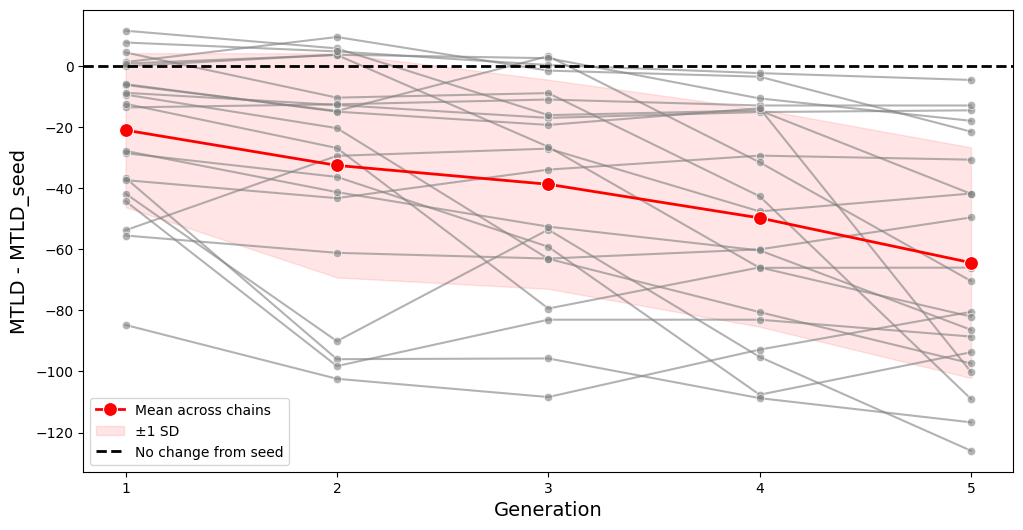

In [31]:
# Distance in MTLD from the chain's seed text (gen 0)

# get seed MTLD for each chain (generation == 0)
seed_mtld = (
    texts_data[texts_data['generation'] == 0]
    .set_index('chain')['lex_rich:mtld']
    .rename('seed_mtld')
)

# join seed_mtld back and compute difference
texts_data = texts_data.join(seed_mtld, on='chain')
texts_data['mtld_dist_to_seed'] = (texts_data['lex_rich:mtld'] - texts_data['seed_mtld'])
texts_data = texts_data.drop(columns=['seed_mtld'])
plot_data = texts_data[texts_data['generation'] > 0]

# mean per generation
mean_dist_to_seed = plot_data.groupby('generation')['mtld_dist_to_seed'].mean().reset_index()
std_dist_to_seed = plot_data.groupby('generation')['mtld_dist_to_seed'].std().reset_index()

# plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_data, x='generation', y='mtld_dist_to_seed', units='chain', estimator=None, marker='o', alpha=0.6, color='gray')
sns.lineplot(data=mean_dist_to_seed, x='generation', y='mtld_dist_to_seed', color='red', marker='o', markersize=10, linewidth=2, label='Mean across chains')
plt.fill_between(std_dist_to_seed['generation'], mean_dist_to_seed['mtld_dist_to_seed'] - std_dist_to_seed['mtld_dist_to_seed'], mean_dist_to_seed['mtld_dist_to_seed'] + std_dist_to_seed['mtld_dist_to_seed'], color='red', alpha=0.1, label='±1 SD')
plt.axhline(0, color='black', linestyle='--', linewidth=2, label='No change from seed')
# plt.title('MTLD Distance to Seed Across Generations by Chain')
plt.xlabel('Generation', fontsize=14)
plt.xticks(range(1, 6))
plt.ylabel('MTLD - MTLD_seed', fontsize=14)
plt.legend()
plt.show()

## Distance to previous generation

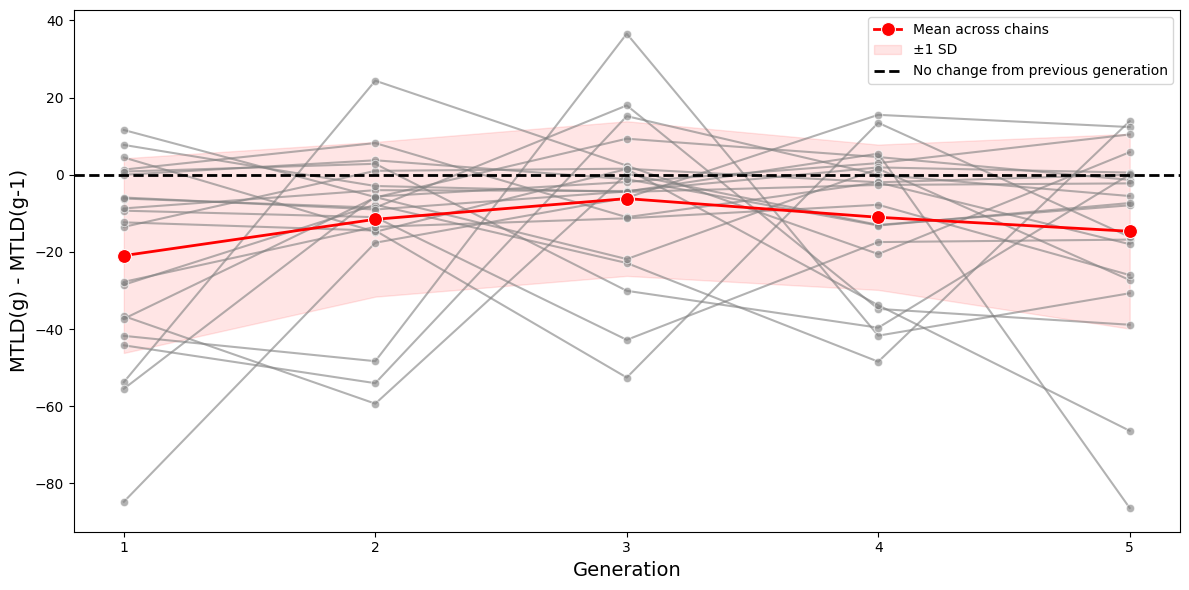

In [32]:
# Change in MTLD between consecutive generations within each chain

texts_data = texts_data.sort_values(['chain', 'generation'])

# shift MTLD within each chain to get the previous generation's value
texts_data['mtld_prev_gen'] = texts_data.groupby('chain')['lex_rich:mtld'].shift(1)
texts_data['mtld_dist_to_prev'] = (texts_data['lex_rich:mtld'] - texts_data['mtld_prev_gen'])

# average per generation
mean_data = texts_data.groupby('generation')['mtld_dist_to_prev'].mean().reset_index()
std_data = texts_data.groupby('generation')['mtld_dist_to_prev'].std().reset_index()

# generation 0 has no previous generation 
plot_data = texts_data[texts_data['generation'] > 0]

plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_data, x='generation', y='mtld_dist_to_prev', units='chain', estimator=None, marker='o', alpha=0.6, color='gray')
sns.lineplot(data=mean_data, x='generation', y='mtld_dist_to_prev', color='red', marker='o', markersize=10, linewidth=2, label='Mean across chains')
plt.fill_between(std_data['generation'], mean_data['mtld_dist_to_prev'] - std_data['mtld_dist_to_prev'], mean_data['mtld_dist_to_prev'] + std_data['mtld_dist_to_prev'], color='red', alpha=0.1, label='±1 SD')
plt.axhline(0, color='black', linestyle='--', linewidth=2, label='No change from previous generation')
# plt.title('MTLD Distance to Previous Generation Across Generations by Chain')
plt.xlabel('Generation', fontsize=14)
plt.xticks(range(1, 6))
plt.ylabel('MTLD(g) - MTLD(g-1)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

## Cross-chain lexical diversity

In [33]:
# compute mtld on aggregated texts from all chains for each generation

lex_div_per_gen = texts_data.groupby('generation')['text'].apply(lambda texts: LexicalRichness(" ".join(texts)).mtld())
lex_div_per_gen

generation
0    251.634106
1    189.527907
2    178.947796
3    161.525731
4    147.566667
5    140.024267
Name: text, dtype: float64

In [34]:
# compare to mean of individual texts' MTLD per generation
mean_mtld_per_gen = texts_data.groupby('generation')['lex_rich:mtld'].mean()
comparison = pd.DataFrame({
    'mean_individual_mtld': mean_mtld_per_gen,
    'aggregated_mtld': lex_div_per_gen
})
comparison

,mean_individual_mtld,aggregated_mtld
generation,,
0,194.871779,251.634106
1,173.907451,189.527907
2,162.360840,178.947796
3,156.179837,161.525731
4,145.157869,147.566667
5,130.504623,140.024267


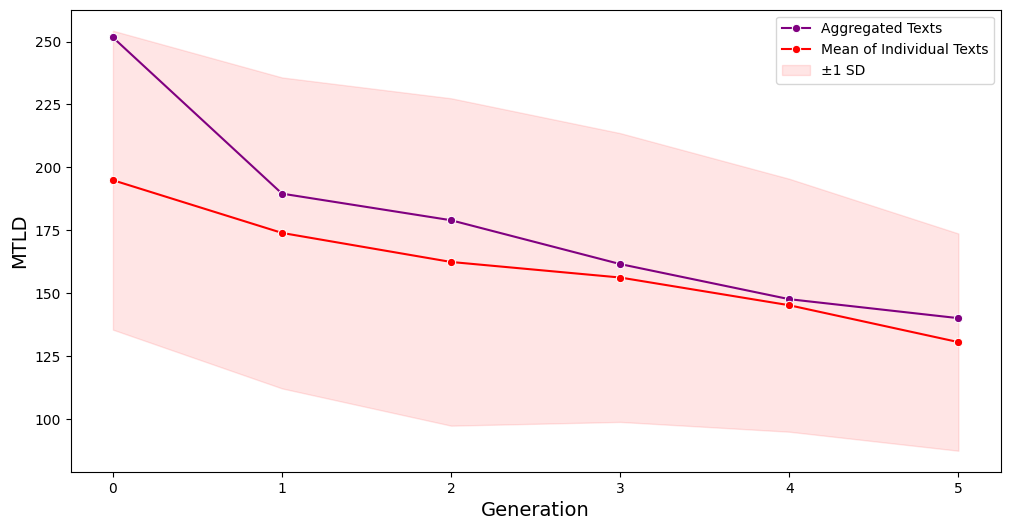

In [35]:
std_data = texts_data.groupby('generation')['lex_rich:mtld'].std()

# plot lexical diversity by generation
plt.figure(figsize=(12, 6))
sns.lineplot(x=lex_div_per_gen.index, y=lex_div_per_gen.values, marker='o', color='purple', label='Aggregated Texts')
sns.lineplot(x=mean_mtld_per_gen.index, y=mean_mtld_per_gen.values, marker='o', color='red', label='Mean of Individual Texts')
plt.fill_between(std_data.index, mean_mtld_per_gen - std_data, mean_mtld_per_gen + std_data, color='red', alpha=0.1, label='±1 SD')
# plt.title('Aggregated Lexical Diversity (MTLD) Across Generations')
plt.xlabel('Generation', fontsize=14)
plt.xticks(range(0, 6))
plt.ylabel('MTLD', fontsize=14)
plt.legend()
# plt.grid()
plt.show()

## Cosine distance

Change trajectory: Are the directions of successive human-authenticating edits consistent/cumulative, alternating, or following another meaningful pattern?

In [36]:
from sentence_transformers import SentenceTransformer
import numpy as np

In [37]:
# load texts_data

texts_data = pd.read_csv("data/processed/text_metrics_with_seed.csv")

In [38]:
embedding_model = SentenceTransformer("all-mpnet-base-v2")

embeddings = embedding_model.encode(texts_data['text'].tolist(), convert_to_numpy=True)
texts_data['embedding'] = list(embeddings)  # (n, dim); n = 105 + 21 = 126

In [39]:
# compute change vectors between consecutive generations within each chain (v_i - v_{i-1}) and cosine similarity between change vectors of consecutive generations (cosine_similarity(v_i - v_{i-1}, v_{i+1} - v_i))

def safe_cosine(v1, v2):
    v1 = np.asarray(v1).reshape(-1)
    v2 = np.asarray(v2).reshape(-1)
    n1 = np.linalg.norm(v1)
    n2 = np.linalg.norm(v2)
    if n1 == 0 or n2 == 0: # if one of the texts was not edited, the change vector will be zero, so cosine similarity is not defined
        return np.nan
    return np.dot(v1, v2) / (n1 * n2)

change_vectors = []
for chain, group in texts_data.groupby('chain'):
    group = group.sort_values('generation')
    embeddings = np.vstack(group['embedding'].values)
    for i in range(1, len(embeddings)-1):
        change_vec_1 = embeddings[i] - embeddings[i-1]
        change_vec_2 = embeddings[i+1] - embeddings[i]
        cos_sim = safe_cosine(change_vec_1, change_vec_2)
        norm1 = np.linalg.norm(change_vec_1)
        norm2 = np.linalg.norm(change_vec_2)
        change_vectors.append({
            'chain': chain,
            'generation': f"{group.iloc[i-1]['generation']}-{group.iloc[i]['generation']} vs {group.iloc[i]['generation']}-{group.iloc[i+1]['generation']}",
            'change_vec_1': change_vec_1,
            'change_vec_2': change_vec_2,
            'norm1': norm1,
            'norm2': norm2,
            'cosine_similarity': cos_sim
        })
change_vectors_df = pd.DataFrame(change_vectors)
# flag rows where either change vector has zero norm (text not edited)
change_vectors_df['not_edited'] = (change_vectors_df['norm1'] == 0) | (change_vectors_df['norm2'] == 0)
change_vectors_df.head()

,chain,generation,change_vec_1,change_vec_2,norm1,norm2,cosine_similarity,not_edited
0,1,0-1 vs 1-2,"[-0.0060203634, -0.002965251, -0.0014983434, 0...","[-0.0013891086, -0.009378042, -0.0015714206, -...",0.099800,0.085793,-0.158436,False
1,1,1-2 vs 2-3,"[-0.0013891086, -0.009378042, -0.0015714206, -...","[0.0024897978, -0.008814303, -0.0046356246, -0...",0.085793,0.232423,-0.153664,False
2,1,2-3 vs 3-4,"[0.0024897978, -0.008814303, -0.0046356246, -0...","[-0.00010493025, 0.0017613927, -0.004372528, -...",0.232423,0.112552,0.031087,False
3,1,3-4 vs 4-5,"[-0.00010493025, 0.0017613927, -0.004372528, -...","[0.00044079497, 0.0029068757, -0.0002216138, 0...",0.112552,0.161303,0.001741,False
4,2,0-1 vs 1-2,"[0.0021532383, -0.0038964506, -0.0012142155, 0...","[0.0065804273, -0.013365531, 0.0009769797, -0....",0.069208,0.122945,-0.059794,False


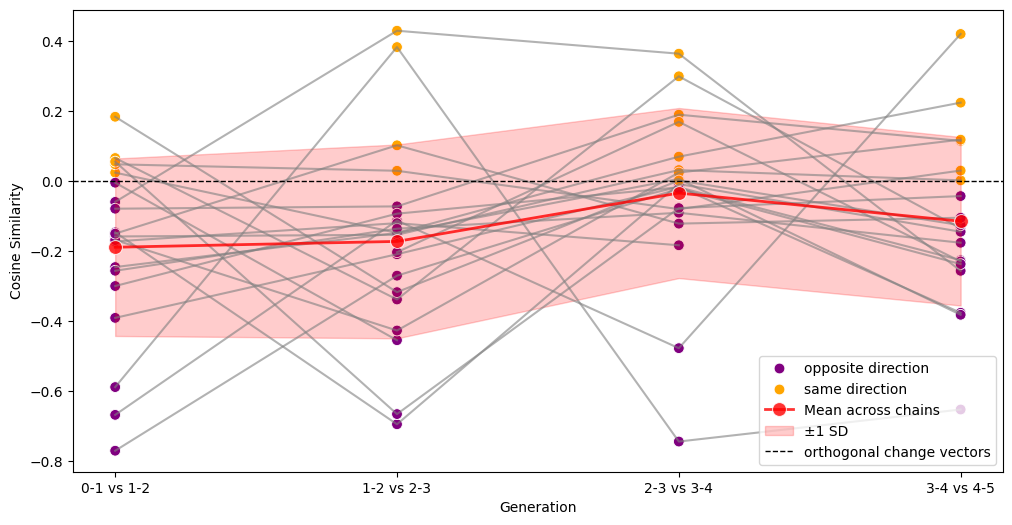

In [40]:
mean_cos_sim_per_gen = change_vectors_df.groupby('generation')['cosine_similarity'].mean().reset_index()
std_cos_sim_per_gen = change_vectors_df.groupby('generation')['cosine_similarity'].std().reset_index()

# plot cosine similarity across generations, color points by sign (>0 orange, <0 purple); mark nan cases
plt.figure(figsize=(12, 6))
cv_plot = change_vectors_df[~change_vectors_df['not_edited']].copy()
# thin gray lines for each chain to show trajectories (exclude not_edited rows)
sns.lineplot(data=cv_plot, x='generation', y='cosine_similarity', units='chain', estimator=None, color='gray', alpha=0.6)
# add a sign column for coloring
cv_plot['sign'] = cv_plot['cosine_similarity'].apply(lambda v: 'same direction' if v > 0 else 'opposite direction')
palette = {'same direction': 'orange', 'opposite direction': 'purple'}
# overlay points colored by sign
sns.scatterplot(data=cv_plot, x='generation', y='cosine_similarity', hue='sign', palette=palette, s=60)
sns.lineplot(data=mean_cos_sim_per_gen, x='generation', y='cosine_similarity', color='red', marker='o', markersize=10, linewidth=2, alpha=0.8, label='Mean across chains')
plt.fill_between(std_cos_sim_per_gen['generation'], mean_cos_sim_per_gen['cosine_similarity'] - std_cos_sim_per_gen['cosine_similarity'], mean_cos_sim_per_gen['cosine_similarity'] + std_cos_sim_per_gen['cosine_similarity'], color='red', alpha=0.2, label='±1 SD')
plt.axhline(0, color='black', linestyle='--', linewidth=1, label='orthogonal change vectors')
# plt.title('Cosine Similarity of Change Vectors Between Text Embeddings Across Generations by Chain')
plt.xlabel('Generation')
plt.ylabel('Cosine Similarity')
plt.legend()
plt.show()

NOTE: undefined similarities due to non-edited texts are not plotted

In [41]:
# t-test for whether mean cosine similarity differs from 0
from scipy.stats import ttest_1samp

defined = change_vectors_df['cosine_similarity'].dropna()
t_stat_imp, p_imp = ttest_1samp(defined, 0, alternative='less')
print(f"One-sample t-test (non-NaN, n={len(defined)}): t = {t_stat_imp:.4f}, p = {p_imp}")
print(f"Mean: {defined.mean():.4f}, Std: {defined.std():.4f}\nMin:  {defined.min():.4f}, Max: {defined.max():.4f}")

One-sample t-test (non-NaN, n=80): t = -4.4784, p = 1.2515780855923608e-05
Mean: -0.1286, Std: 0.2568
Min:  -0.7703, Max: 0.4290


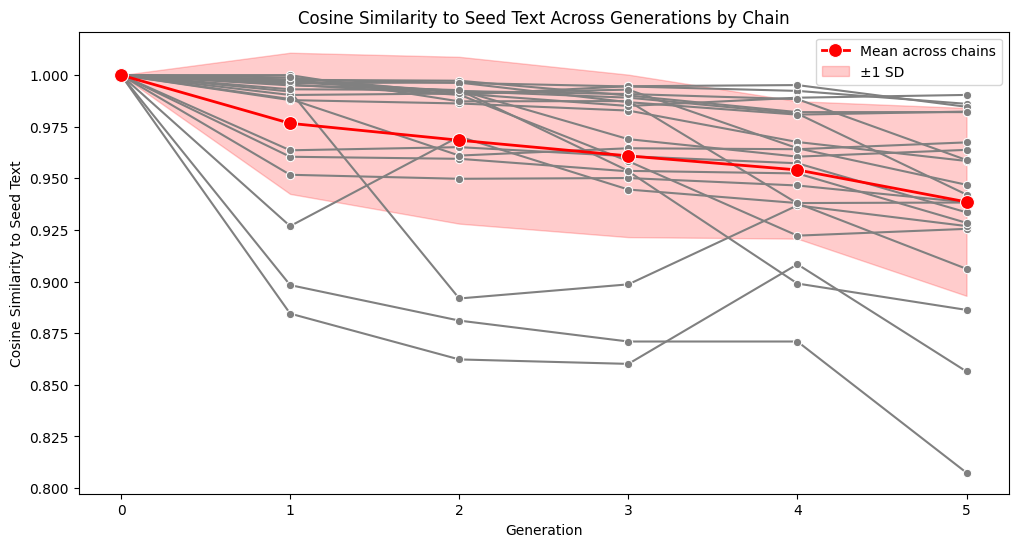

In [42]:
# cos sim to seed text in embedding space (cosine similarity between each text's embedding and the seed text embedding for that chain)

seed_embeddings = texts_data[texts_data['generation'] == 0].set_index('chain')['embedding']

def cosine_to_seed(row):
    seed_emb = seed_embeddings[row['chain']]
    return safe_cosine(row['embedding'], seed_emb)

texts_data['cosine_to_seed'] = texts_data.apply(cosine_to_seed, axis=1)

mean_cosine_to_seed = texts_data.groupby('generation')['cosine_to_seed'].mean().reset_index()
std_cosine_to_seed = texts_data.groupby('generation')['cosine_to_seed'].std().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=texts_data, x='generation', y='cosine_to_seed', units='chain', estimator=None, marker='o', color='gray')
sns.lineplot(data=mean_cosine_to_seed, x='generation', y='cosine_to_seed', color='red', marker='o', markersize=10, linewidth=2, label='Mean across chains')
plt.fill_between(std_cosine_to_seed['generation'], mean_cosine_to_seed['cosine_to_seed'] - std_cosine_to_seed['cosine_to_seed'], mean_cosine_to_seed['cosine_to_seed'] + std_cosine_to_seed['cosine_to_seed'], color='red', alpha=0.2, label='±1 SD')
plt.title('Cosine Similarity to Seed Text Across Generations by Chain')
plt.xlabel('Generation')
plt.xticks(range(0, 6))
plt.ylabel('Cosine Similarity to Seed Text')
plt.legend()
plt.show()

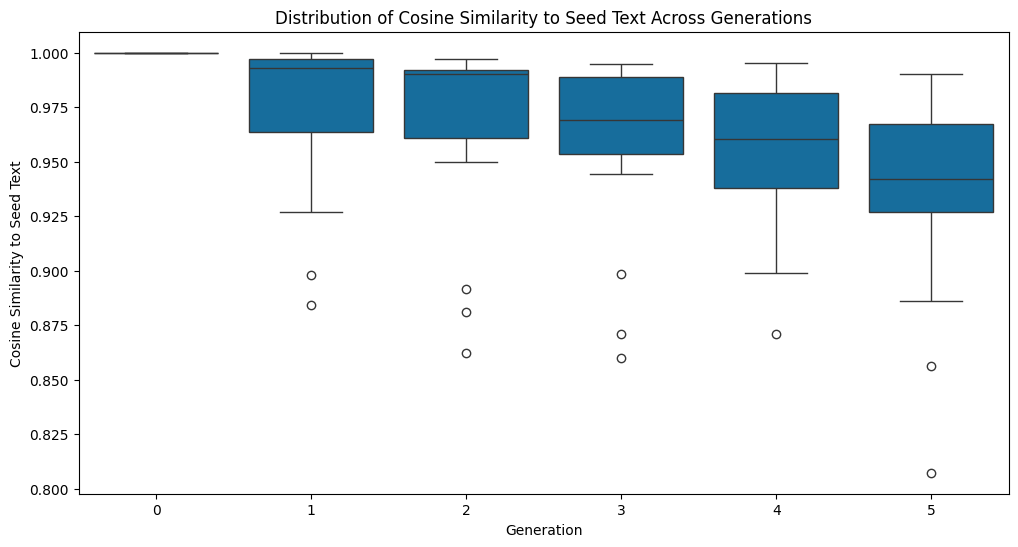

In [43]:
# boxplot of cosine similarity to seed text per generation
plt.figure(figsize=(12, 6))
sns.boxplot(data=texts_data, x='generation', y='cosine_to_seed')
plt.title('Distribution of Cosine Similarity to Seed Text Across Generations')
plt.xlabel('Generation')
plt.xticks(range(0, 6))
plt.ylabel('Cosine Similarity to Seed Text')
plt.show()

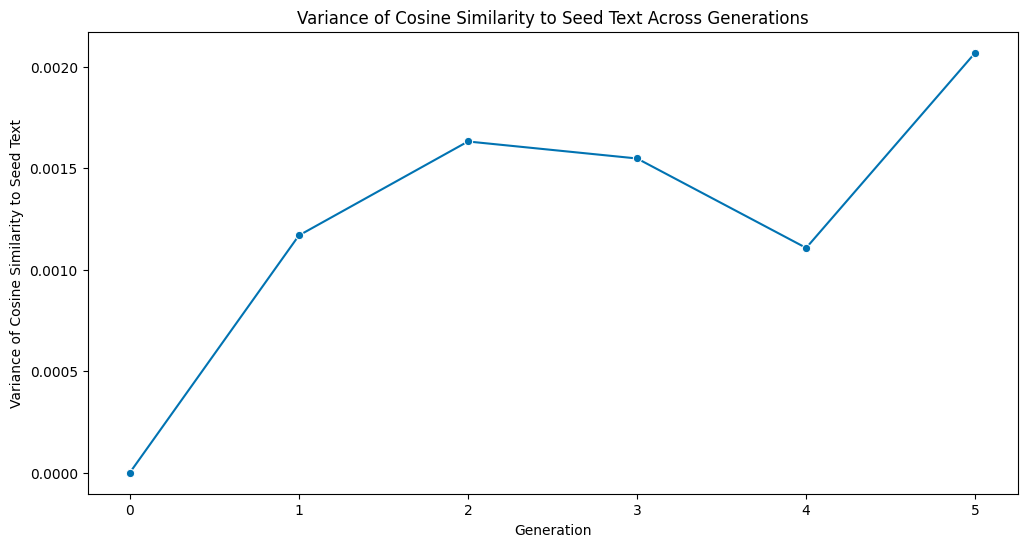

In [44]:
# does the variance increase across generations? plot variance of cosine similarity to seed text per generation
var_cosine_to_seed = texts_data.groupby('generation')['cosine_to_seed'].var().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=var_cosine_to_seed, x='generation', y='cosine_to_seed', marker='o')
plt.title('Variance of Cosine Similarity to Seed Text Across Generations')
plt.xlabel('Generation')
plt.xticks(range(0, 6))
plt.ylabel('Variance of Cosine Similarity to Seed Text')
plt.show()

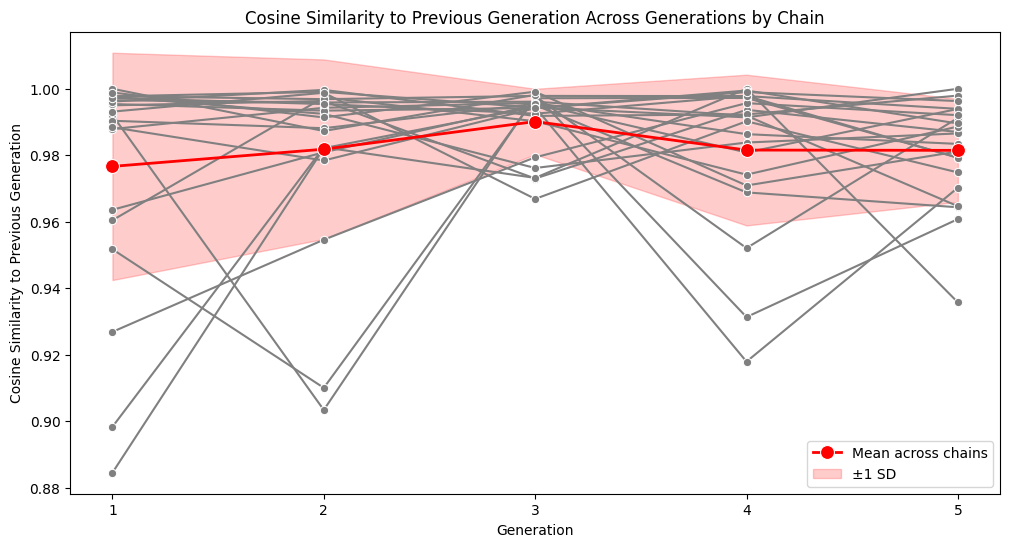

In [45]:
# cos sim to previous generation in embedding space (cosine similarity between each text's embedding and the previous generation's embedding for that chain)
def cosine_to_prev_gen(row):
    if row['generation'] == 0:
        return np.nan
    prev_emb = texts_data[(texts_data['chain'] == row['chain']) & (texts_data['generation'] == row['generation'] - 1)]['embedding'].values
    if len(prev_emb) == 0:
        return np.nan
    return safe_cosine(row['embedding'], prev_emb[0])
texts_data['cosine_to_prev_gen'] = texts_data.apply(cosine_to_prev_gen, axis=1)

mean_cosine_to_prev = texts_data.groupby('generation')['cosine_to_prev_gen'].mean().reset_index()
std_cosine_to_prev = texts_data.groupby('generation')['cosine_to_prev_gen'].std().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=texts_data[texts_data['generation'] > 0], x='generation', y='cosine_to_prev_gen', units='chain', estimator=None, marker='o', color='gray')
sns.lineplot(data=mean_cosine_to_prev[mean_cosine_to_prev['generation'] > 0], x='generation', y='cosine_to_prev_gen', color='red', marker='o', markersize=10, linewidth=2, label='Mean across chains')
plt.fill_between(std_cosine_to_prev['generation'], mean_cosine_to_prev['cosine_to_prev_gen'] - std_cosine_to_prev['cosine_to_prev_gen'], mean_cosine_to_prev['cosine_to_prev_gen'] + std_cosine_to_prev['cosine_to_prev_gen'], color='red', alpha=0.2, label='±1 SD') 
plt.title('Cosine Similarity to Previous Generation Across Generations by Chain')
plt.xlabel('Generation')
plt.xticks(range(1, 6))
plt.ylabel('Cosine Similarity to Previous Generation')
plt.legend()
plt.show()